TANZANIA TOURISM EXPENDITURE PREDICTION

**PREDICTING TOURIST EXPENDITURE IN TANZANIA**

The objecive of this project is to develop a machine learning model that predicts total expenditure of a toursit visiting Tanzania based on demographic characteristics, travel details, and tourism related  activities collected through a national tourism survey

**Machine learning tasks**
* Data loading and inspection

* Data quality assessment
* Exploratory data analysis (EDA)
* Missing value treatment
* Feature engineering
* Data preprocessing
* Model development and validation
* Model optimization





**Importing required libraries
We will begin by importing the libraries that will be required for the proeject. This will support data manipulation, exploratory data analysis ,visualisation, preprocesing , model development and performance evaluation

In [ ]:
# Data manipulation and analysis tools
import pandas as pd
import numpy as np

# Data visualisation tool
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

# Avoiding unnecessary warnings
import warnings
warnings.filterwarnings('ignore')

print('All libraries loaded successfully')

All libraries loaded successfully


**LOADING THE DATA**

The first step is to load the datasets and verify that they have been imported correctly


In [ ]:



# Loading the data into pandas
train = pd.read_csv('/content/Train.csv')
test = pd.read_csv('/content/Test.csv')


# Save test IDs
test_ids = test['ID'].copy()

print(f'Training data : {train.shape}')
print(f'Test data     : {test.shape}')
print(f'Test IDs saved: {len(test_ids)}')
print('\nFirst 3 rows of training data:')
print(train.head(3))

Training data : (4809, 23)
Test data     : (1601, 22)
Test IDs saved: 1601

First 3 rows of training data:
          ID         country age_group        travel_with  total_female  \
0     tour_0      SWIZERLAND     45-64  Friends/Relatives           1.0   
1    tour_10  UNITED KINGDOM     25-44                NaN           1.0   
2  tour_1000  UNITED KINGDOM     25-44              Alone           0.0   

   total_male                         purpose     main_activity  \
0         1.0            Leisure and Holidays  Wildlife tourism   
1         0.0            Leisure and Holidays  Cultural tourism   
2         1.0  Visiting Friends and Relatives  Cultural tourism   

          info_source tour_arrangement  ... package_transport_tz  \
0  Friends, relatives      Independent  ...                   No   
1              others      Independent  ...                   No   
2  Friends, relatives      Independent  ...                   No   

  package_sightseeing package_guided_tour package_

**Inspecting the data structure**

In this step will identify the variables available, assess data types, evaluate missing values, detect duplicate records, and verify that raining and test datsets are consistent


In [ ]:
#Display dimension of the datesets
print(f"Training dataset shape: ", train.shape)
print(f"Test dataset shape: ", test.shape)

Training dataset shape:  (4809, 23)
Test dataset shape:  (1601, 22)


In [ ]:
#Display all variable names

train.columns.tolist()


['ID',
 'country',
 'age_group',
 'travel_with',
 'total_female',
 'total_male',
 'purpose',
 'main_activity',
 'info_source',
 'tour_arrangement',
 'package_transport_int',
 'package_accomodation',
 'package_food',
 'package_transport_tz',
 'package_sightseeing',
 'package_guided_tour',
 'package_insurance',
 'night_mainland',
 'night_zanzibar',
 'payment_mode',
 'first_trip_tz',
 'most_impressing',
 'total_cost']

In [ ]:
#Check for column consistency between the test and train datasets
set(train.columns)-set(test.columns)

{'total_cost'}

In [ ]:
#Data structure overview
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4809 entries, 0 to 4808
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     4809 non-null   object 
 1   country                4809 non-null   object 
 2   age_group              4809 non-null   object 
 3   travel_with            3695 non-null   object 
 4   total_female           4806 non-null   float64
 5   total_male             4804 non-null   float64
 6   purpose                4809 non-null   object 
 7   main_activity          4809 non-null   object 
 8   info_source            4809 non-null   object 
 9   tour_arrangement       4809 non-null   object 
 10  package_transport_int  4809 non-null   object 
 11  package_accomodation   4809 non-null   object 
 12  package_food           4809 non-null   object 
 13  package_transport_tz   4809 non-null   object 
 14  package_sightseeing    4809 non-null   object 
 15  pack

In [ ]:
#Missing values
missing=train.isnull().sum()
missing[missing>0].sort_values(ascending=False)

,0
travel_with,1114
most_impressing,313
total_male,5
total_female,3


In [ ]:
#value cardinality analyis
train.nunique().sort_values(ascending=False)

,0
ID,4809
total_cost,1637
country,105
night_mainland,64
night_zanzibar,34
total_male,14
total_female,14
main_activity,9
info_source,8
purpose,7


**Target variable analysis**

The target  variable is assessed in terms of  distribution , range, and variability

In [ ]:
#Descriptive statistics
train['total_cost'].describe()

,total_cost
count,4.809000e+03
mean,8.114389e+06
std,1.222490e+07
min,4.900000e+04
25%,8.121750e+05
50%,3.397875e+06
75%,9.945000e+06
max,9.953288e+07


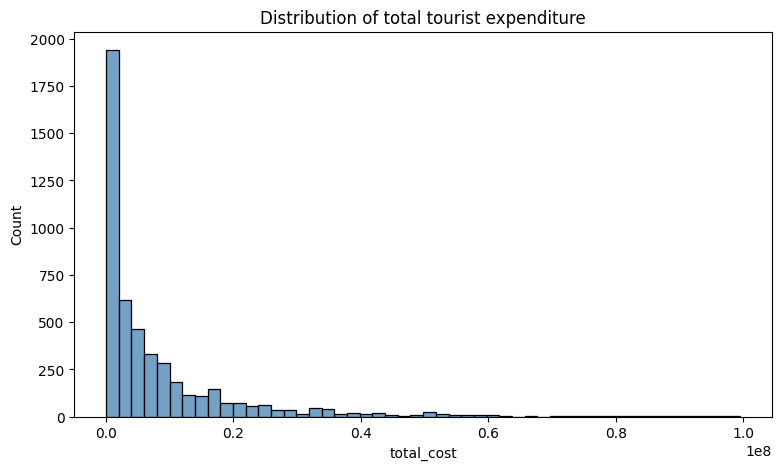

In [ ]:
#Target distribution
plt.figure(figsize=(9,5))
sns.histplot(train['total_cost'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of total tourist expenditure')
plt.show()

- Impute missing categorical values with "Unknown" to preserve behavioral information
- Fill missing numerical values using median imputation to reduce outlier sensitivity
- Apply log1p transformation to total_cost to reduce skewness and stabilize variance
- Drop or carefully encode high-cardinality identifier variable ID.
- Use one-hot encoding for low-cardinality categorical variables.
- Use CatBoost or target encoding for high-cardinality categorical variables.
Keep binary package variables (package_*) as they are without transformation.
Create engineered features such as total group size (male + female).
- Create total nights feature (mainland + Zanzibar stays).
- Add a solo traveler indicator based on travel_with missingness or value.
Prefer tree-based models (CatBoost, LightGBM, XGBoost) over linear models.


**EXPLORATORY DATA ANALYSIS (EDA**)

We want to understand the relationship between features ad the target variable, identify key patterns in tourist behaviour and generate insights to guid feature engineering and model development

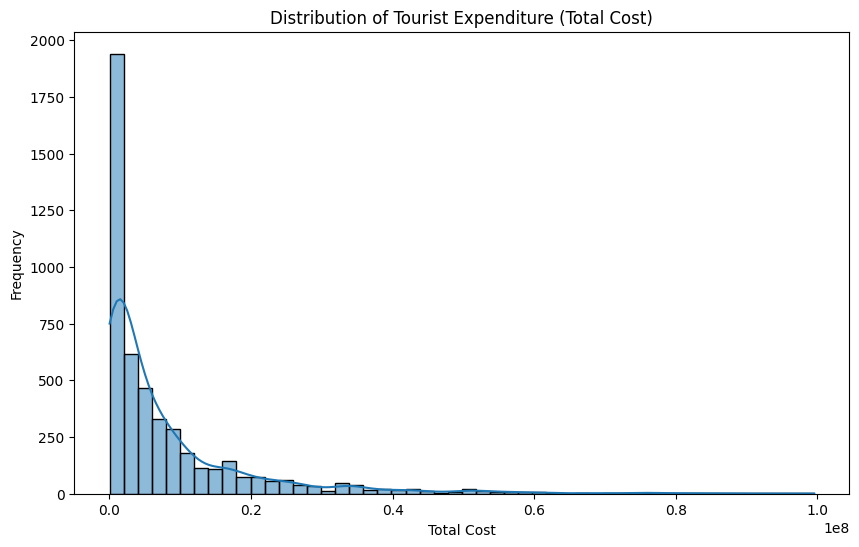

In [ ]:
#Target variable distribution

plt.figure(figsize=(10,6))
sns.histplot(train['total_cost'], bins=50, kde=True)
plt.title("Distribution of Tourist Expenditure (Total Cost)")
plt.xlabel("Total Cost")
plt.ylabel("Frequency")
plt.show()


In [ ]:
#Summary statistics
train['total_cost'].describe()

,total_cost
count,4.809000e+03
mean,8.114389e+06
std,1.222490e+07
min,4.900000e+04
25%,8.121750e+05
50%,3.397875e+06
75%,9.945000e+06
max,9.953288e+07


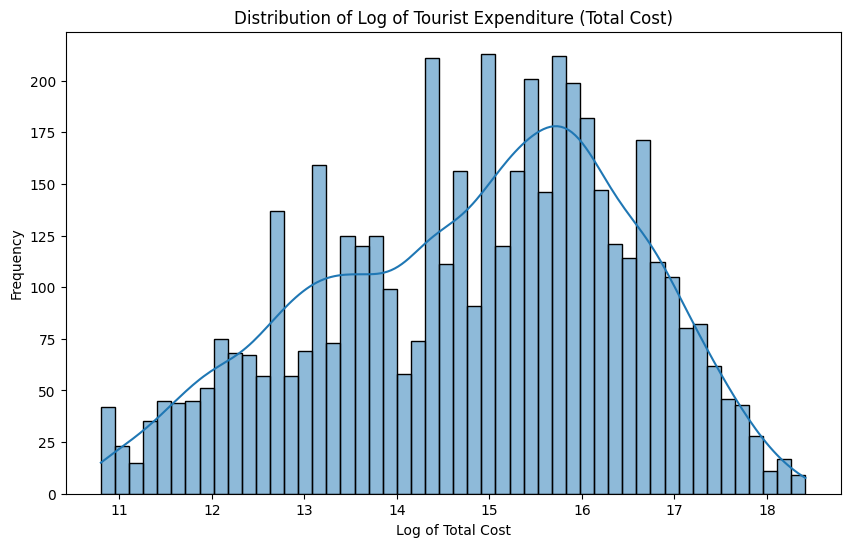

In [ ]:
#Log transforming the target variable
train['log_total_cost']=np.log1p(train['total_cost'])
plt.figure(figsize=(10,6))
sns.histplot(train['log_total_cost'], bins=50, kde=True )
plt.title("Distribution of Log of Tourist Expenditure (Total Cost)")
plt.xlabel("Log of Total Cost")
plt.ylabel("Frequency")
plt.show()

In [ ]:

top_countries=train.groupby('country')['total_cost'].mean().sort_values(ascending=False).head(10)
print(top_countries)

country
DOMINICA     3.315000e+07
COSTARICA    2.718300e+07
SLOVENIA     1.906237e+07
TUNISIA      1.574625e+07
AUSTRALIA    1.474802e+07
DENMARK      1.456879e+07
ISRAEL       1.430542e+07
RUSSIA       1.358321e+07
COLOMBIA     1.331525e+07
TAIWAN       1.321396e+07
Name: total_cost, dtype: float64


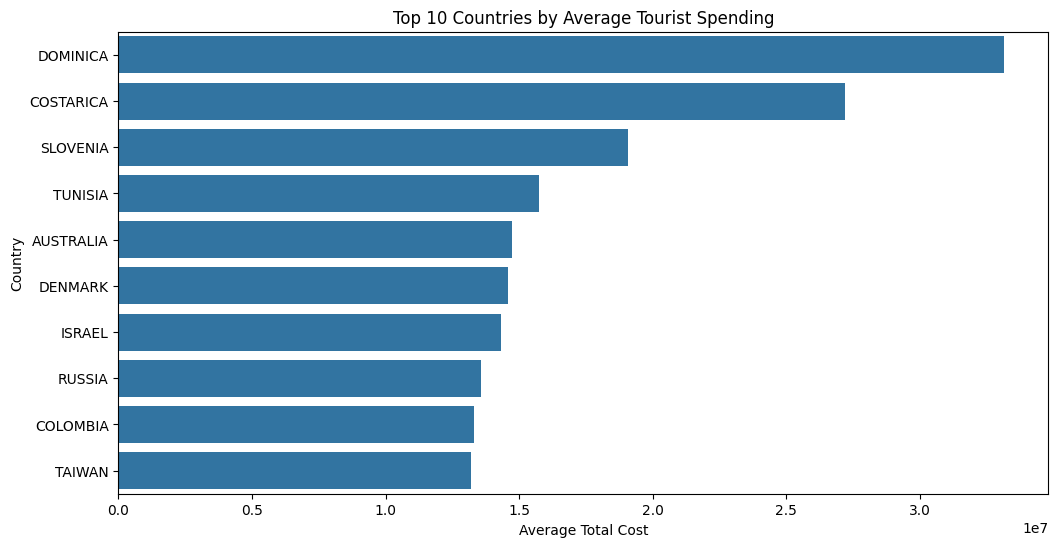

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Countries by Average Tourist Spending")
plt.xlabel("Average Total Cost")
plt.ylabel("Country")
plt.show()


In [ ]:
#Purpose of visit vs spending
purpose_spending=train.groupby('purpose')['total_cost'].mean().sort_values(ascending=False)
print(purpose_spending)

purpose
Leisure and Holidays              1.195114e+07
Scientific and Academic           4.031990e+06
Volunteering                      3.950565e+06
Visiting Friends and Relatives    3.190776e+06
Meetings and Conference           2.453004e+06
Business                          1.782438e+06
Other                             1.592155e+06
Name: total_cost, dtype: float64


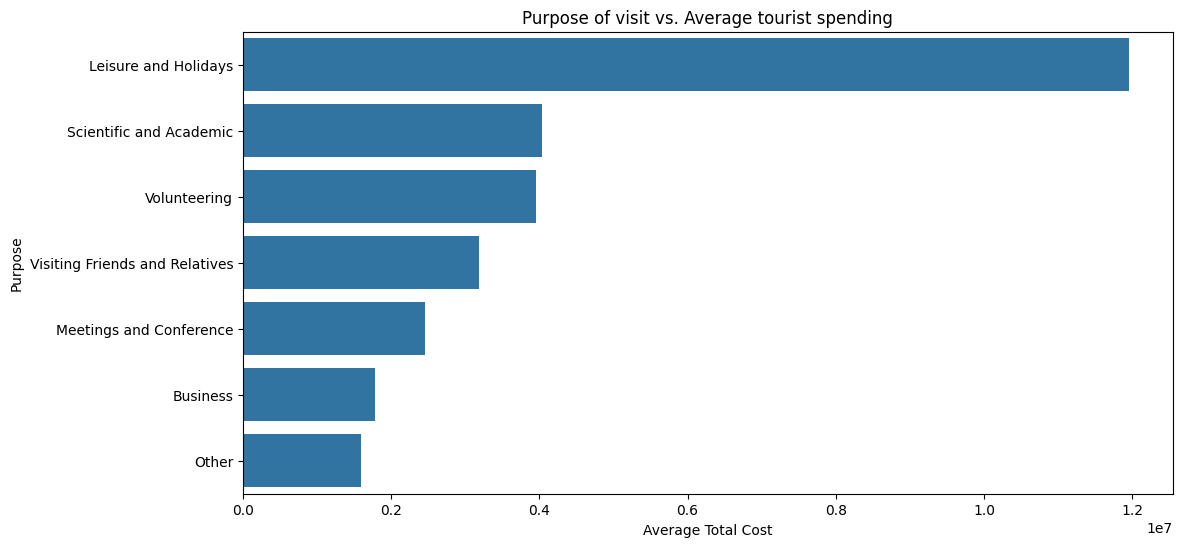

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x=purpose_spending.values, y=purpose_spending.index)
plt.title("Purpose of visit vs. Average tourist spending")
plt.xlabel("Average Total Cost")
plt.ylabel("Purpose")
plt.show()

In [ ]:
train.main_activity.value_counts()

,count
main_activity,
Wildlife tourism,2259
Beach tourism,1025
Hunting tourism,457
Conference tourism,367
Cultural tourism,359
Mountain climbing,234
business,58
Bird watching,37
Diving and Sport Fishing,13


In [ ]:
#Main activity vs spending
activity_spending=train.groupby('main_activity')['total_cost'].mean().sort_values(ascending=False)
print(activity_spending)

main_activity
Diving and Sport Fishing    1.709434e+07
Wildlife tourism            1.059533e+07
Conference tourism          1.030680e+07
business                    8.125078e+06
Beach tourism               7.524837e+06
Bird watching               4.216563e+06
Cultural tourism            3.991139e+06
Hunting tourism             1.911327e+06
Mountain climbing           1.862857e+06
Name: total_cost, dtype: float64


Text(0, 0.5, 'Main Activity')

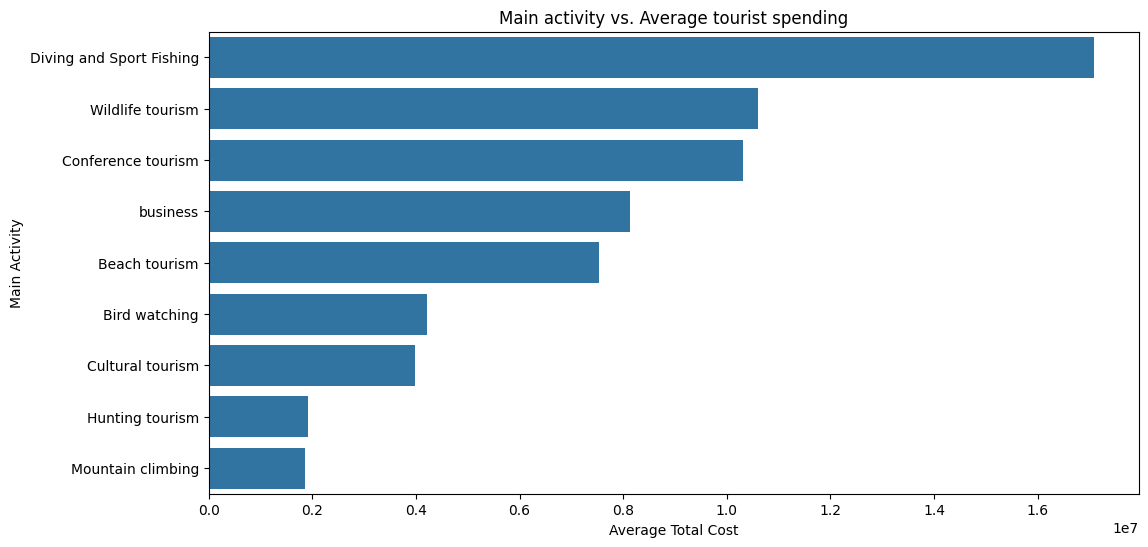

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x=activity_spending.values, y=activity_spending.index)
plt.title("Main activity vs. Average tourist spending")
plt.xlabel("Average Total Cost")
plt.ylabel("Main Activity")

In [ ]:
#Package vs spending

package_cols=['package_transport_int','package_accomodation','package_food','package_transport_tz','package_sightseeing','package_guided_tour','package_insurance']
package_means={}
for col in package_cols:
  package_means[col]=train.groupby(col)['total_cost'].mean()

package_means


{'package_transport_int': package_transport_int
 No     4.670738e+06
 Yes    1.607605e+07
 Name: total_cost, dtype: float64,
 'package_accomodation': package_accomodation
 No     2.897812e+06
 Yes    1.426461e+07
 Name: total_cost, dtype: float64,
 'package_food': package_food
 No     3.504681e+06
 Yes    1.426067e+07
 Name: total_cost, dtype: float64,
 'package_transport_tz': package_transport_tz
 No     3.841902e+06
 Yes    1.471301e+07
 Name: total_cost, dtype: float64,
 'package_sightseeing': package_sightseeing
 No     4.887023e+06
 Yes    1.530340e+07
 Name: total_cost, dtype: float64,
 'package_guided_tour': package_guided_tour
 No     4.969253e+06
 Yes    1.472729e+07
 Name: total_cost, dtype: float64,
 'package_insurance': package_insurance
 No     6.704244e+06
 Yes    1.599382e+07
 Name: total_cost, dtype: float64}

In [ ]:
#create  package score
train['package_score']=train[package_cols].apply(
    lambda x: sum(x=='Yes'),axis=1)

# We have created a new feature

In [ ]:
train['package_score'].head(10)

,package_score
0,0
1,0
2,0
3,5
4,0
5,2
6,0
7,7
8,0
9,0


**Numeric Variable Data**

We analyze numerical features to understand how trip intensity (group size and duration) influences toursit expenditure. These variables  help capture the scal and duration of travel


In [ ]:
#Summary Statistics
train[['total_male', 'total_female', 'night_mainland', 'night_zanzibar']].describe()

,total_male,total_female,night_mainland,night_zanzibar
count,4804.000000,4806.000000,4809.000000,4809.000000
mean,1.009575,0.926758,8.488043,2.304429
std,1.138865,1.288242,10.427624,4.227080
min,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,3.000000,0.000000
50%,1.000000,1.000000,6.000000,0.000000
75%,1.000000,1.000000,11.000000,4.000000
max,44.000000,49.000000,145.000000,61.000000


In [ ]:
#Total group size
train['total_group_size']=train['total_male']+train['total_female']
print(train['total_group_size'].head(10))

0    2.0
1    1.0
2    1.0
3    2.0
4    1.0
5    1.0
6    1.0
7    2.0
8    1.0
9    1.0
Name: total_group_size, dtype: float64


In [ ]:
#total nights
train['total_nights']=train['night_mainland']+train['night_zanzibar']
print(train['total_nights'].head(10))

0    13.0
1    21.0
2    32.0
3    11.0
4    11.0
5    12.0
6     9.0
7    13.0
8     4.0
9     5.0
Name: total_nights, dtype: float64


In [ ]:
train[['total_group_size', 'total_nights','total_cost']].describe()

,total_group_size,total_nights,total_cost
count,4801.000000,4809.000000,4.809000e+03
mean,1.932306,10.792472,8.114389e+06
std,2.073996,10.779025,1.222490e+07
min,0.000000,0.000000,4.900000e+04
25%,1.000000,4.000000,8.121750e+05
50%,2.000000,8.000000,3.397875e+06
75%,2.000000,14.000000,9.945000e+06
max,93.000000,145.000000,9.953288e+07


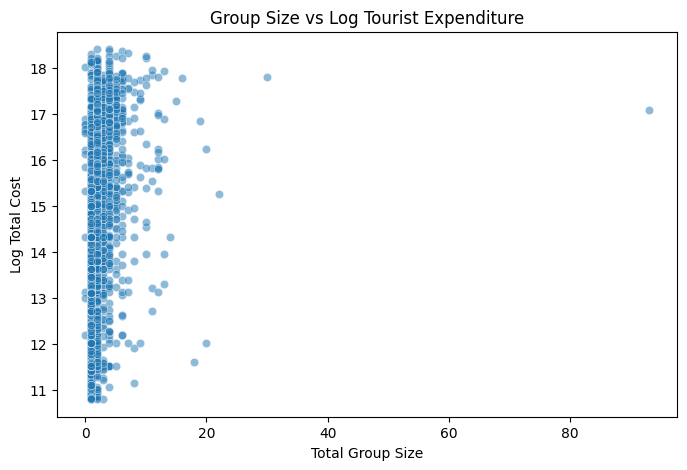

In [ ]:
#Relationship between travel intensity and expenditure
# Relationship between group size and expenditure
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=train,
    x='total_group_size',
    y='log_total_cost',
    alpha=0.5
)

plt.title('Group Size vs Log Tourist Expenditure')
plt.xlabel('Total Group Size')
plt.ylabel('Log Total Cost')
plt.show()

In [ ]:
#correlation
train[['total_group_size', 'total_nights', 'total_cost']].corr()

,total_group_size,total_nights,total_cost
total_group_size,1.000000,0.041008,0.272399
total_nights,0.041008,1.000000,0.076723
total_cost,0.272399,0.076723,1.000000


FEATURE ENGINEERING

In [ ]:
train.columns

Index(['ID', 'country', 'age_group', 'travel_with', 'total_female',
       'total_male', 'purpose', 'main_activity', 'info_source',
       'tour_arrangement', 'package_transport_int', 'package_accomodation',
       'package_food', 'package_transport_tz', 'package_sightseeing',
       'package_guided_tour', 'package_insurance', 'night_mainland',
       'night_zanzibar', 'payment_mode', 'first_trip_tz', 'most_impressing',
       'total_cost', 'log_total_cost', 'package_score', 'total_group_size',
       'total_nights'],
      dtype='object')

In [ ]:
#Already created log_total_cost, package_score, total_group_size, 'total_nights'
# Solo traveller indicator
train['is_solo_traveler'] = (train['total_group_size'] <= 1).astype(int)

# Zanzibar visit indicator
train['visited_zanzibar'] = (train['night_zanzibar'] > 0).astype(int)




In [ ]:
#Test features
# Total group size
test['total_group_size'] = test['total_male'] + test['total_female']

# Total nights spent in Tanzania
test['total_nights'] = test['night_mainland'] + test['night_zanzibar']

# Solo traveller indicator
test['is_solo_traveler'] = (test['total_group_size'] <= 1).astype(int)

# Zanzibar visit indicator
test['visited_zanzibar'] = (test['night_zanzibar'] > 0).astype(int)

# Package intensity score
test['package_score'] = test[package_cols].eq('Yes').sum(axis=1)

# Verify
test[['total_group_size',
      'total_nights',
      'is_solo_traveler',
      'visited_zanzibar',
      'package_score']].head()

,total_group_size,total_nights,is_solo_traveler,visited_zanzibar,package_score
0,2.0,13,0,1,7
1,4.0,13,0,0,2
2,3.0,21,0,1,0
3,2.0,4,0,1,0
4,4.0,10,0,0,4


**DATA PREPROCESSING**
Before training  model, we need to prepare the data by:
- Handling missing valuses
- Separating features and target
- Encoding categorical vairables
- Creating  train validation data sets


In [ ]:
# Check for missing values
print('Missing Values')
print(train.isnull().sum())



Missing Values
ID                          0
country                     0
age_group                   0
travel_with              1114
total_female                3
total_male                  5
purpose                     0
main_activity               0
info_source                 0
tour_arrangement            0
package_transport_int       0
package_accomodation        0
package_food                0
package_transport_tz        0
package_sightseeing         0
package_guided_tour         0
package_insurance           0
night_mainland              0
night_zanzibar              0
payment_mode                0
first_trip_tz               0
most_impressing           313
total_cost                  0
log_total_cost              0
package_score               0
total_group_size            8
total_nights                0
is_solo_traveler            0
visited_zanzibar            0
dtype: int64


HANDLING MISSING VALUES

In [ ]:
# travel_with — fill with 'Unknown' because its a Missing Not At Random Data
train['travel_with'] = train['travel_with'].fillna('Unknown')
test['travel_with']  = test['travel_with'].fillna('Unknown')

# most_impressing — fill with 'None' because they left no comment
train['most_impressing'] = train['most_impressing'].fillna('None')
test['most_impressing']  = test['most_impressing'].fillna('None')

# total_female and total_male — fill with median because they are numbers
train['total_female'] = train['total_female'].fillna(train['total_female'].median())
test['total_female']  = test['total_female'].fillna(test['total_female'].median())

train['total_male'] = train['total_male'].fillna(train['total_male'].median())
test['total_male']  = test['total_male'].fillna(test['total_male'].median())

# Confirm everything is clean
print('Missing values after fixing:')
print(train.isnull().sum())

Missing values after fixing:
ID                       0
country                  0
age_group                0
travel_with              0
total_female             0
total_male               0
purpose                  0
main_activity            0
info_source              0
tour_arrangement         0
package_transport_int    0
package_accomodation     0
package_food             0
package_transport_tz     0
package_sightseeing      0
package_guided_tour      0
package_insurance        0
night_mainland           0
night_zanzibar           0
payment_mode             0
first_trip_tz            0
most_impressing          0
total_cost               0
log_total_cost           0
package_score            0
total_group_size         8
total_nights             0
is_solo_traveler         0
visited_zanzibar         0
dtype: int64


TARGET ENCODING FOR COUNTRY
- Instead of creating many 0/1 columns for country we replace each country with the average spendingof tourists from that country
- This gives the model much more useful information

In [ ]:
"""
 Calculate average spending per country from training data
country_avg = train.groupby('country')['total_cost'].mean()
print('Average spending per country (top 10):')
print(country_avg.sort_values(ascending=False).head(10))

# Replace country name with average spending
train['country_encoded'] = train['country'].map(country_avg)

# For test data — use the same mapping from training data
# If a country appears in test but not train — use overall average
overall_avg = train['total_cost'].mean()
test['country_encoded'] = test['country'].map(country_avg).fillna(overall_avg)

print(f'\n Target encoding done!')
print(f'Sample — country vs encoded value:')
print(train[['country', 'country_encoded']].head(10))
"""



"\n Calculate average spending per country from training data\ncountry_avg = train.groupby('country')['total_cost'].mean()\nprint('Average spending per country (top 10):')\nprint(country_avg.sort_values(ascending=False).head(10))\n\n# Replace country name with average spending\ntrain['country_encoded'] = train['country'].map(country_avg)\n\n# For test data — use the same mapping from training data\n# If a country appears in test but not train — use overall average\noverall_avg = train['total_cost'].mean()\ntest['country_encoded'] = test['country'].map(country_avg).fillna(overall_avg)\n\nprint(f'\n Target encoding done!')\nprint(f'Sample — country vs encoded value:')\nprint(train[['country', 'country_encoded']].head(10))\n"

  ENCODING
1. We convert text columns to numbers so the model can read them
2. Label Encoding for Yes/No columns
3. One Hot Encoding for columns with many options

In [ ]:
X = train.drop(columns=['ID', 'total_cost'])
y = train['total_cost']

X_test = test.drop(columns=['ID'])

print(X.shape, y.shape, X_test.shape)

(4809, 27) (4809,) (1601, 26)


In [ ]:
#Split the data
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train set:", X_train.shape)
print("Validation set:", X_valid.shape)

Train set: (3847, 27)
Validation set: (962, 27)


In [ ]:
# Identify categorical columns
cat_cols = X_train.select_dtypes(include='object').columns

cat_cols

Index(['country', 'age_group', 'travel_with', 'purpose', 'main_activity',
       'info_source', 'tour_arrangement', 'package_transport_int',
       'package_accomodation', 'package_food', 'package_transport_tz',
       'package_sightseeing', 'package_guided_tour', 'package_insurance',
       'payment_mode', 'first_trip_tz', 'most_impressing'],
      dtype='object')

In [ ]:
encoders = {}

for col in cat_cols:
    le = LabelEncoder()

    # Fit ONLY on training data
    X_train[col] = le.fit_transform(X_train[col].astype(str))

    # Handle unseen categories in validation/test
    X_valid[col] = X_valid[col].astype(str)
    X_test[col] = X_test[col].astype(str)

    # Extend classes safely
    unseen_valid = set(X_valid[col]) - set(le.classes_)
    unseen_test = set(X_test[col]) - set(le.classes_)

    if unseen_valid or unseen_test:
        le.classes_ = np.append(le.classes_, list(unseen_valid | unseen_test))

    # Transform
    X_valid[col] = le.transform(X_valid[col])
    X_test[col] = le.transform(X_test[col])

    encoders[col] = le

int64      20
float64     7
Name: count, dtype: int64


In [ ]:
"""

# Label Encoding — converts Yes/No to 1/0
le = LabelEncoder()

yes_no_cols = ['package_transport_int', 'package_accomodation',
               'package_food', 'package_transport_tz',
               'package_sightseeing', 'package_guided_tour',
               'package_insurance', 'first_trip_tz', 'tour_arrangement']

for col in yes_no_cols:
    train[col] = le.fit_transform(train[col])
    test[col]  = le.fit_transform(test[col])

print('Label Encoding done!')

# One Hot Encoding — creates a separate column for each category
ohe_cols = ['age_group', 'travel_with',
            'purpose', 'main_activity', 'info_source', 'payment_mode']

train = pd.get_dummies(train, columns=ohe_cols)
test  = pd.get_dummies(test,  columns=ohe_cols)

# Make sure train and test have exactly the same columns
test = test.reindex(columns=train.columns, fill_value=0)

print('One Hot Encoding done!')
print(f'Total columns now: {train.shape[1]}')"""

"\n\n# Label Encoding — converts Yes/No to 1/0\nle = LabelEncoder()\n\nyes_no_cols = ['package_transport_int', 'package_accomodation',\n               'package_food', 'package_transport_tz',\n               'package_sightseeing', 'package_guided_tour',\n               'package_insurance', 'first_trip_tz', 'tour_arrangement']\n\nfor col in yes_no_cols:\n    train[col] = le.fit_transform(train[col])\n    test[col]  = le.fit_transform(test[col])\n\nprint('Label Encoding done!')\n\n# One Hot Encoding — creates a separate column for each category\nohe_cols = ['age_group', 'travel_with',\n            'purpose', 'main_activity', 'info_source', 'payment_mode']\n\ntrain = pd.get_dummies(train, columns=ohe_cols)\ntest  = pd.get_dummies(test,  columns=ohe_cols)\n\n# Make sure train and test have exactly the same columns\ntest = test.reindex(columns=train.columns, fill_value=0)\n\nprint('One Hot Encoding done!')\nprint(f'Total columns now: {train.shape[1]}')"

SCALING
- We bring all number columns to the same range so no column dominates the model unfairly

In [ ]:
# Columns we want to scale
scale_cols = ['total_female', 'total_male', 'night_mainland',
              'night_zanzibar', 'total_nights', 'total_people', 'package_count']

# Fit scaler on train and apply same transformation to test
scaler = StandardScaler()
train[scale_cols] = scaler.fit_transform(train[scale_cols])
test[scale_cols]  = scaler.transform(test[scale_cols])

print('Scaling done!')
print('\nNumbers after scaling:')
print(train[scale_cols].head(3))

KeyError: "['total_people', 'package_count'] not in index"

PREPARE FEATURES AND TARGET
 X = all the information we give the model (questions)
    y = what we want the model to predict (answer)

In [ ]:
# Drop columns the model doesn't need
# ID = just a label, most_impressing = free text, total_cost = the answer
# Separate features (X) and target (y)

X = train.drop(
    columns=[
        'ID',
        'most_impressing',
        'total_cost'
    ]
)

y = train['total_cost']

X_test = test.drop(
    columns=[
        'ID',
        'most_impressing'
    ],
    errors='ignore'
)

# Remove text column that the model cannot understand
X = X.drop(columns=['country'], errors='ignore')
X_test = X_test.drop(columns=['country'], errors='ignore')


print(f'X shape      : {X.shape}')
print(f'y shape      : {y.shape}')
print(f'X_test shape : {X_test.shape}')

STEP 9: SPLIT DATA INTO TRAINING AND VALIDATION SETS
1. We hide 20% of data from the model to test if it truly learned
2. Training set   → model learns from this (80%)
3. Validation set → we test the model on this (20%)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training tourists   : {X_train.shape[0]}')
print(f'Validation tourists : {X_val.shape[0]}')
print(f'Total              : {X_train.shape[0] + X_val.shape[0]}')

LOG TRANSFORM THE TARGET
- Tourist spending ranges from 49,000 to 99,000,000 TZS
- That huge range makes it hard for the model to predict accurately
- Log transformation compresses the range making it easier to learn

In [ ]:
# Transform target to log scale
y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)

print('Before log transform:')
print(f'Min  : {y_train.min():,.0f} TZS')
print(f'Max  : {y_train.max():,.0f} TZS')
print(f'Range: {y_train.max() - y_train.min():,.0f} TZS')

print('\nAfter log transform:')
print(f'Min  : {y_train_log.min():.2f}')
print(f'Max  : {y_train_log.max():.2f}')
print(f'Range: {y_train_log.max() - y_train_log.min():.2f}')

In [ ]:
# Confirm it worked
text_cols = X.select_dtypes(include='object').columns.tolist()
print(f'Text columns remaining : {text_cols}')
print(f'X shape      : {X.shape}')
print(f'X_test shape : {X_test.shape}')
print(f'Columns match: {list(X.columns) == list(X_test.columns)}')

TRAINING THE MODEL
- We use XGBoost — it learns from its own mistakes making it more accurate than a basic model

In [ ]:
# Build the model with carefully chosen settings
model = XGBRegressor(
    n_estimators=500,      # number of trees to build
    max_depth=6,           # maximum questions per tree
    learning_rate=0.05,    # how fast the model learns
    subsample=0.8,         # use 80% of data per tree
    colsample_bytree=0.8,  # use 80% of columns per tree
    random_state=42,       # ensures same results every run
    n_jobs=-1              # use full computer power
)

# Train the model on our training data
model.fit(
    X_train, y_train_log,
    eval_set=[(X_val, y_val_log)],
    verbose=False
)

print('Model trained successfully!')

EVALUATING THE MODEL
- We test how accurate our model is on the validation data, Remember the model has never seen this data before

In [ ]:
# Generate predictions on validation data
log_predictions = model.predict(X_val)

# Convert predictions back from log scale to real TZS values
real_predictions = np.expm1(log_predictions)
real_actual      = np.expm1(y_val_log)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(real_actual, real_predictions))

print(f'Our RMSE          : {rmse:,.0f} TZS')
print(f'Average spending  : {real_actual.mean():,.0f} TZS')
print(f'\nThis means on average we are off by {rmse:,.0f} TZS')
print(f'Compared to average spending of {real_actual.mean():,.0f} TZS')

REMOVING EXTREME OUTLIERS
- A few tourists spending 99 million TZS confuse the model
- We remove the top 1% of spenders to help the model learn the patterns of normal tourists better

In [ ]:
# Find the 99th percentile spending
upper_limit = y_train.quantile(0.99)
print(f'Upper limit (99th percentile): {upper_limit:,.0f} TZS')

# Keep only tourists below that limit
mask = y_train <= upper_limit
X_train_clean = X_train[mask]
y_train_clean = y_train[mask]

print(f'Tourists before removing outliers: {len(X_train)}')
print(f'Tourists after removing outliers : {len(X_train_clean)}')
print(f'Outliers removed                 : {len(X_train) - len(X_train_clean)}')

RETRAINING MODEL WITH CLEAN DATA
-Now we train again without the extreme outliers

In [ ]:
# Log transform the clean target
y_train_clean_log = np.log1p(y_train_clean)

# Retrain the model
model.fit(
    X_train_clean, y_train_clean_log,
    eval_set=[(X_val, y_val_log)],
    verbose=False
)

# Evaluate again
log_predictions   = model.predict(X_val)
real_predictions  = np.expm1(log_predictions)
real_actual       = np.expm1(y_val_log)

rmse = np.sqrt(mean_squared_error(real_actual, real_predictions))

print(f'RMSE before removing outliers: 9,636,761 TZS')
print(f'RMSE after removing outliers : {rmse:,.0f} TZS')

if rmse < 9_636_761:
    print('Model improved!')
else:
    print(' No improvement lets try something else')

TUNING XGBOOST FOR BETTER ACCURACY
- We adjust the model settings to reduce errors

In [ ]:
# Use original training data (with outliers back in)
y_train_log = np.log1p(y_train)

# Retrain with better settings
model = XGBRegressor(
    n_estimators=1000,      # more trees = more learning
    max_depth=5,            # slightly shallower trees
    learning_rate=0.01,     # slower learning = more accurate
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=5,     # ignore patterns with less than 5 tourists
    gamma=0.1,              # only split if it improves significantly
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train_log,
    eval_set=[(X_val, y_val_log)],
    verbose=False
)

# Evaluate
log_predictions  = model.predict(X_val)
real_predictions = np.expm1(log_predictions)
real_actual      = np.expm1(y_val_log)

rmse = np.sqrt(mean_squared_error(real_actual, real_predictions))

print(f'Previous RMSE : 9,636,761 TZS')
print(f'New RMSE      : {rmse:,.0f} TZS')

if rmse < 9_636_761:
    print('Model improved!')
else:
    print('Still no improvement')

RESETING TO BEST MODEL
- Our local RMSE is misleading due to high spenders in
- validation set, We go back to our proven settings.

In [ ]:
y_train_log = np.log1p(y_train)

model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Train on FULL training data — not just 80%
# More data = better predictions
model.fit(X, np.log1p(y), verbose=False)

print('Model trained on full data!')

GENERATING THE FINAL PREDICTIONS
- We predict tourist spending for the test data
- Then convert back from log scale to real TZS values

In [ ]:
areare# Predict on test data
log_predictions = model.predict(X_test)

# Convert back from log to real TZS values
final_predictions = np.expm1(log_predictions)

# Make sure no negative predictions exist
final_predictions = np.maximum(final_predictions, 0)

print(f'Predictions generated : {len(final_predictions)}')
print(f'Min predicted         : {final_predictions.min():,.0f} TZS')
print(f'Max predicted         : {final_predictions.max():,.0f} TZS')
print(f'Mean predicted        : {final_predictions.mean():,.0f} TZS')

In [ ]:
#Summary statistics
train[['total_male', 'total_female', 'night_mainland', 'night_zanzibar']].describe()

CREATING SUBMISSION FILE
- We combine test IDs with our predictions and save in the format expected

In [ ]:
# Create submission dataframe
submission = pd.DataFrame({
    'ID':         test_ids.values,
    'total_cost': final_predictions
})

# Confirm it looks correct
print('Submission preview:')
print(submission.head(10))
print(f'\nShape    : {submission.shape}')
print(f'\nValue summary:')
print(submission['total_cost'].describe())

# Save to CSV
submission.to_csv('submission.csv', index=False)
print('\n submission.csv saved!')

# Download
from google.colab import files
files.download('submission.csv')
print('Download started!')

BLENDING STEP 1: TRAIN RANDOM FOREST
- We train a second model on the same data
- Random Forest works differently from XGBoost so it will catch different patterns

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

# Train on full data
rf_model.fit(X, np.log1p(y))
print(' Random Forest trained!')

BLENDING STEP 2: COMBINE BOTH MODELS
- We average XGBoost and Random Forest predictions giving equal weight to both models

In [ ]:
# Get predictions from both models
xgb_preds = np.expm1(model.predict(X_test))
rf_preds  = np.expm1(rf_model.predict(X_test))

# Blend — simple average of both
blended_preds = (xgb_preds + rf_preds) / 2

# Make sure no negatives
blended_preds = np.maximum(blended_preds, 0)

print(f'XGBoost mean  : {xgb_preds.mean():,.0f} TZS')
print(f'Random Forest : {rf_preds.mean():,.0f} TZS')
print(f'Blended mean  : {blended_preds.mean():,.0f} TZS')

BLENDING STEP 3: CREATE SUBMISSION

In [ ]:
submission = pd.DataFrame({
    'ID':         test_ids.values,
    'total_cost': blended_preds
})

print(' Submission preview:')
print(submission.head())
print(f'\nShape: {submission.shape}')

submission.to_csv('submission.csv', index=False)

from google.colab import files
files.download('submission.csv')
print(' Download started!')